In [1]:
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(parent_dir)
task_name = 'LogicCircuits_4s_6r_MAK_REINFORCE_SIL'
print('Working directory set to:', parent_dir)

Working directory set to: /local0/rossin/git/CRN-GenerativeAI


In [2]:
# Import general packages
from openpyxl import Workbook, load_workbook
from openpyxl.utils import get_column_letter
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error
from RL4CRN.rewards.stochastic import dynamic_tracking_error_SSA

In [3]:
# Set the logger to use Comet
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
api_key = "vhIR3uyqsKyU4L7SA8fLCfTSC"
logger = CometLogger(
    api_key=api_key,
    project=task_name,        
    workspace="redsnic", 
    name=f'{task_name}_{timestamp}',
)
logger = logger.experiment

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/redsnic/logiccircuits-4s-6r-mak-reinforce-sil/fd41f6a565144c0bb066825f61956054



In [4]:
# Construct the template CRN
# add dilution and production reactions for all species
productions = []
dilutions = []
n_inputs = 4
species_labels = [f'X_{i+1}' for i in range(n_inputs)] 
for i,s in enumerate(species_labels):
    productions.append(MassAction(reactant_labels=[], product_labels=[s], input_channels=[f'u_{i+1}'], params=[1.], params_controllability=[True]))
    # dilutions.append(MassAction(reactant_labels=[s], product_labels=[], input_channels=[None], params=[1.], params_controllability=[True])) 

# add diluting output
species_labels.append('OUT') # add output species label
# dilutions.append(MassAction(reactant_labels=['OUT'], product_labels=[], input_channels=[None], params=[1.0], params_controllability=[True]))
# productions.append(MassAction(reactant_labels=[], product_labels=['OUT'], input_channels=[None], params=[.5], params_controllability=[True]))

# support_nodes = ['S1', 'S2']
# species_labels.extend(support_nodes) # add support nodes to species labels

crn_template = IOCRN(productions + dilutions, output_labels=['OUT'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
library = construct_mass_action_library(species_labels=species_labels, order=2)
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1', 'u_2', 'u_3', 'u_4'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3', 'X_4'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
∅ ----> X_4;  [MAK(1.0, u_4)]
Library of possible reactions:
Number of reactions: 421
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X_1;  [MAK(None)]
R2: ∅ ----> X_2;  [MAK(None)]
R3: ∅ ----> X_3;  [MAK(None)]
R4: ∅ ----> X_4;  [MAK(None)]
R5: ∅ ----> OUT;  [MAK(None)]
R6: ∅ ----> X_1 + X_1;  [MAK(None)]
R7: ∅ ----> X_1 + X_2;  [MAK(None)]
R8: ∅ ----> X_1 + X_3;  [MAK(None)]
R9: ∅ ----> X_1 + X_4;  [MAK(None)]
R10: ∅ ----> OUT + X_1;  [MAK(None)]
R11: ∅ ----> X_2 + X_2;  [MAK(None)]
R12: ∅ ----> X_2 + X_3;  [MAK(None)]
R13: ∅ ----> X_2 + X_4;  [MAK(None)]
R14: ∅ ----> OUT + X_2;  [MAK(None)]
R15: ∅ ----> X_3 + X_3;  [MAK(None)]
R16: ∅ ----> X_3 + X_4;  [MAK(None)]
R17: ∅ ----> OUT + X_3;  [MAK(None)]
R18: ∅ ----> X_4 + X_4;  [MAK(None)]
R19: ∅ ----> OUT + X_4;  [MAK(None)]
R20: ∅ --

In [5]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

Using device: cuda
Number of CPUs available: 128


In [6]:
# Flags and filenames
save_flag = True                                                # Save the agent checkpoint
load_flag = False                                               # Load the agent checkpoint 
train_flag = True                                               # Train the agent
save_sheet_flag = True                                          # Save the configuration to an Excel sheet

save_filename = timestamp + '.pth'                              # Filename for saving the agent checkpoint
load_filename = ''                                              # Filename for loading the agent checkpoint
file_name = f"{task_name}.xlsx"             # Filename for saving the Excel sheet

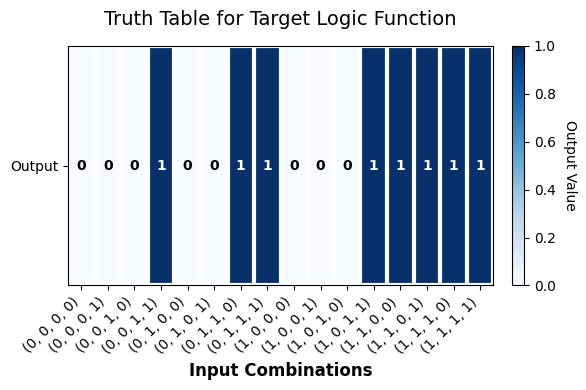

In [7]:
# %%
from RL4CRN.utils.visualizations import plot_truth_table

# Hyperparameters
max_added_reactions = 6                             # Maximum number of reactions
N_CPUs = os.cpu_count()                             # Number of CPUs          
N = 10*N_CPUs                                       # Number of samples (batch size)    
width = 1024                                        # Width of the neural networks  
depth = 5                                           # Depth of the neural networks 
deep_layer_size = 1024*10                           # Size of the deep layer encoding the CRNs
allow_input_influence = False                       # Allow input influence in the policy
learning_rate = 1e-4                                # Learning rate for the optimizer 
hall_of_fame_size = 30                              # Size of the hall of fame  
entropy_scheduler = {                               # Entropy scheduler parameters 
    'entropy_weight': 1e-3, 
    'topk_entropy_weight' : 1.0,
    'remainder_entropy_weight' : 1.0,
    'entropy_update_coefficient': 1, 
    'entropy_schedule': 1000, 
    'minimum_entropy_weight': 0.0
}
entropy_weights_per_head = {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0} 
structure_head_temperature = {"target_entropy_ratio_to_max": np.log(5)/np.log(M), "initial_temperature": 1.0, "rate": 0.0, "current_temperature": 1.0}
risk_scheduler = {                                  # Risk scheduler parameters
    'risk': 0.9, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 1000
}
epoch_num = 300                                     # Number of epochs for training
render_schedule = 10                                 # Render every # of epochs
render_mode = {                                     # Mode of the experiment
    'style': 'logger', 
    'task': 'transients + logic', 
    'format': 'image',
    'topology': True,
    'bounds': [2.5]
}
# Ordering specific parameters
ordering_parameters = {
    'enforce_ordering': False,
    'constraint_weight' : float('inf')
}
# SIL settings
sil_settings = {
    'sil_loss_weight': 1.0,
    'sil_use_adaptive_baseline': False,
    'sil_baseline_annealing_rate': 0.95
}

render_n_best = 10                                                    # Number of best CRNs to plot responses for
render_disregard_percentage = 0.99                                    # Percentage of worst CRNs to disregard in the responses plotting

# Parameter distribution for the reactions added by the agent
continuous_distribution = {"type": 'lognormal_1D'}

# Time horizon for the simulation
t_f = 100                                           # Final time for the simulation
N_t = 1000                                          # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
# all combination of inputs between 0 and 1 
nums = [0., 1.]
u_list = [np.array(u) for u in product(*[nums for _ in range(n_inputs)])] # list of input combinations, each input is a numpy array of shape (p,)

# --- define the logic function ---
logic_target = lambda u : (u[0] and u[1]) or (u[1] and u[2]) or (u[2] and u[3])  # target logic function

# Construct the reference setpoints
r_list = [np.array([float(logic_target(u))]) for u in u_list]  # list of reference outputs, each output is a numpy array of shape (q,)

# Plot the truth table for the target logic function
plot_truth_table(u_list, r_list, title='Truth Table for Target Logic Function')

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.01 for _ in species_labels]])

# Construct the weights for the performance metric
# w = np.ones(N_t)
# w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
# w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
# w = w[np.newaxis, :]
# No transients
w = np.zeros((1, N_t))
w[:, -1] = 1.0 * N_t

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)

In [8]:
if save_sheet_flag:
    sheet_name = "Data"
    headers = [
        "Timestamp", "URL",
        "Epochs Completed", "Successful", "Saved", "Comments",
        "Learning Rate", "Epochs #",
        "(m, n, p, N)",
        "NN Depth", "NN Width", "Deep Layer Size", "CPUs #",
        "Entropy Scheduler",
        "Risk Scheduler",
        "Render Schedule", "HoF Size",
        "Simulation Time", "Time Steps #",
        "Initial Conditions #", "Input Scenarios#",
        "Continuous Distribution", "Entropy Weights per Head",
        "Structure Head Temperature",
        "Ordering Enforced",
        "SIL Settings"
    ]

    data_row = [
        timestamp, logger.url,
        None, None, None, None,
        learning_rate, epoch_num,
        str((max_added_reactions, len(species_labels), p, N)),
        depth, width, deep_layer_size, N_CPUs,
        str(entropy_scheduler),
        str(risk_scheduler),
        render_schedule, hall_of_fame_size,
        t_f, N_t, len(ic.values), len(u_list),
        str(continuous_distribution), str(entropy_weights_per_head),
        str(structure_head_temperature),
        f"Yes: {ordering_parameters['constraint_weight']}" if ordering_parameters['enforce_ordering'] else "No",
        str(sil_settings)
    ]

    if os.path.exists(file_name):
        wb = load_workbook(file_name)
        if sheet_name in wb.sheetnames:
            ws = wb[sheet_name]
        else:
            ws = wb.create_sheet(sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    # Write headers if sheet is empty
    if ws.max_row == 1 and ws.max_column == 1 and ws.cell(row=1, column=1).value is None:
        for col, header in enumerate(headers, start=1):
            ws.cell(row=1, column=col, value=header)

    # Append experiment as next row
    next_row = ws.max_row + 1
    for col, value in enumerate(data_row, start=1):
        ws.cell(row=next_row, column=col, value=value)

    # Freeze header row and add filter
    ws.freeze_panes = "B1" 
    ws.auto_filter.ref = ws.dimensions

    # === Auto-fit column widths (except URL column) ===
    # URL column is column 2 (B), we leave its width unchanged.
    url_col_index = 2

    for col in range(1, ws.max_column + 1):
        if col == url_col_index:
            continue  # keep URL column width as-is

        max_length = 0
        for row in range(1, ws.max_row + 1):
            cell = ws.cell(row=row, column=col)
            value = cell.value
            if value is not None:
                # Convert to string to measure length
                length = len(str(value))
                if length > max_length:
                    max_length = length

        # Some padding so text isn't touching the cell border
        adjusted_width = max_length + 2 if max_length > 0 else 10
        col_letter = get_column_letter(col)
        ws.column_dimensions[col_letter].width = adjusted_width

    wb.save(file_name)
    print(f"New experiment data saved in row {next_row} of '{file_name}'.")

New experiment data saved in row 3 of 'LogicCircuits_4s_6r_MAK_REINFORCE_SIL.xlsx'.


In [9]:
# Construct parallel environments
crn_0 = crn_template.clone()
mult_env = ParallelEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, N_CPUs=N_CPUs, logger=logger)
# mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [10]:
# Construct the policy
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
rate_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
masks = {"continuous": library.get_parameter_mask(mode="continuous"), "discrete": library.get_parameter_mask(mode="discrete"), "logit": library.get_logit_mask()}
policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                    combinatorial_bias_enabled=ordering_parameters["enforce_ordering"], constraint_strength=ordering_parameters["constraint_weight"])

if ordering_parameters["enforce_ordering"]:
    policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                        combinatorial_bias_enabled=ordering_parameters["enforce_ordering"], constraint_strength=ordering_parameters["constraint_weight"])
else:
    policy = AddReactionByIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head)

# Construct the agent
agent = REINFORCEAgent(policy, allow_input_influence=False, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, sil_settings=sil_settings, device=device)
if load_flag:
    agent.policy.load_state_dict(torch.load(load_filename+'.pth', map_location=device))

In [11]:
# Construct the interfaces
observer = ExplicitObserver(reaction_library=library, allow_input_observation=allow_input_influence)
tensorizer = ExplicitTensorizer(device=device)
actuator = LibraryActuator(reaction_library=library)
stepper = IOCRNStepper()

In [ ]:
# Training Loop   
if train_flag:
    agent.policy.train()
    for i in tqdm(range(epoch_num)):
        mult_env.reset()
        for j in range(max_added_reactions):
            observations = mult_env.observe(observer, tensorizer)
            actions, raw_actions = agent.act(observations, actuator)
            out = mult_env.step(actions, stepper, raw_actions=raw_actions)
        rewards = mult_env.get_reward(compute_reward)
        agent.update(rewards, step_iteration=i, hof=mult_env.hall_of_fame, observer=observer, tensorizer=tensorizer, stepper=stepper, use_sil=True, sil_weighting_scheme='uniform', sil_batch_size=None)
        if i % render_schedule == 0:
            mult_env.render(rewards, n_best=render_n_best, disregarded_percentage=render_disregard_percentage, mode=render_mode)

  0%|          | 0/300 [00:00<?, ?it/s]


[cvHandleFailure, Error: -15] At t = 3.93601510153852, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 9.24119528715459, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 8.04920621160096, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.68008692223319, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 3.51009314782317, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 42.6578554610884, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 56.4776835236558, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.01610839487753, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 8.43841610291065, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 14.5066398106131, unable to satisfy inequality constraints.


[cvHandle

  0%|          | 1/300 [01:03<5:14:52, 63.19s/it]


[cvHandleFailure, Error: -15] At t = 17.374880715966, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 2.5038266599285, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 2.30412916055208, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 12.5606645088535, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 8.56485304215187, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 8.56485304215187, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 34.1424891803987, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 3.23640380454738, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 3.6210652816, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 4.95974902551642, unable to satisfy inequality constraints.


[cvHandleFailur

  1%|          | 2/300 [01:53<4:35:08, 55.40s/it]

...

 24%|██▎       | 71/300 [1:09:28<3:58:56, 62.61s/it]


[cvHandleFailure, Error: -15] At t = 11.2332886152228, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 11.6078509658412, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -4] At t = 5.16564308002631 and h = 11.0343783301718, the corrector convergence test failed repeatedly or with |h| = hmin.


[cvHandleFailure, Error: -15] At t = 6.27876857608203, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.52779628854101, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 8.49092401107037, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 4.88209544344924, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 13.3961668654212, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 3.5088003128771, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.06672039104076, una

 24%|██▍       | 72/300 [1:10:26<3:52:00, 61.06s/it]


[cvHandleFailure, Error: -15] At t = 4.8063392631806, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 9.67250968061485, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.11707830647258, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 4.8577141796393, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 18.9023224021976, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 3.89618481594182, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.15520898565185, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 4.83402485853563, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 6.2695491932754, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 4.81671102441477, unable to satisfy inequality constraints.


[cvHandleFai

 24%|██▍       | 73/300 [1:11:28<3:52:53, 61.56s/it]

In [ ]:
hall_of_fame_crns = [env.state for env in mult_env.hall_of_fame]
if save_flag:
    if not os.path.exists('models'):
        os.makedirs('models')
    if not os.path.exists('hof'):
        os.makedirs('hof')
    torch.save(agent.policy.state_dict(), 'models/' + save_filename)
    torch.save(hall_of_fame_crns, 'hof/hall_of_fame_' + save_filename)